### **1. Distribuzioni di probabilità**
Genera 1000 valori casuali da una distribuzione gamma con parametro di forma pari a 1.
Suggerimento: il parametro di forma viene passato come primo argomento quando si "congela" la distribuzione.

Traccia l’istogramma del campione e sovrapponi la PDF della distribuzione.

Stima il parametro di forma dal campione usando il metodo fit.

Extra:
Le distribuzioni hanno molti metodi utili. Esplorali usando il completamento automatico con il tasto TAB.

Traccia la funzione di distribuzione cumulativa (CDF).

Calcola la varianza.

In [ ]:
%pip install numpy
%pip install matplotlib
%pip install scipy

In [2]:
import numpy as np
import matplotlib.pyplot as plt
import scipy as sp


In [3]:
distribuzione = sp.stats.gamma(1, scale = 1)
valori = distribuzione.rvs(size=1000)

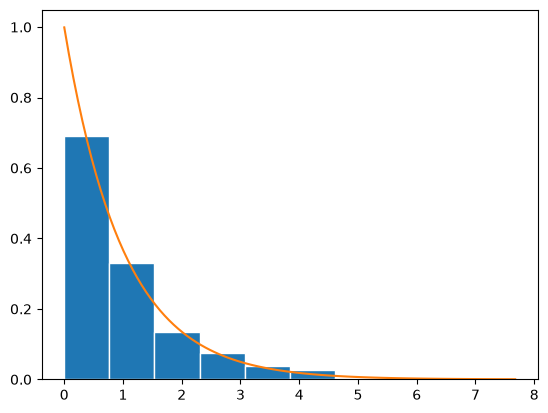

In [4]:
plt.hist(valori, edgecolor = "white", density = True)
x = np.linspace(min(valori), max(valori), 100)
plt.plot(x, distribuzione.pdf(x), label = "PDF")

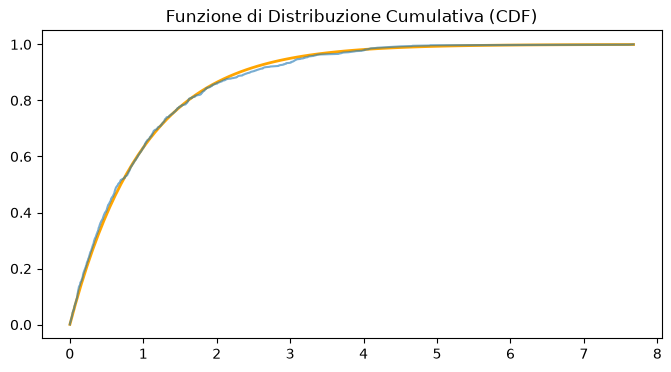

(np.float64(1.0), np.float64(1.0682925202793314))

In [5]:
shape_est, loc_est, scale_est = sp.stats.gamma.fit(valori)
#Funzione di distribuzione cumulativa (CDF)
plt.figure(figsize=(8, 4))
plt.plot(x, distribuzione.cdf(x), color='orange', label="CDF teorica", linewidth=2)
# CDF empirica dei dati campionati
x_sorted = np.sort(valori)
y_cdf = np.arange(1, len(valori) + 1) / len(valori)
plt.plot(x_sorted, y_cdf, alpha=0.6, label="CDF empirica (campione)")
plt.title("Funzione di Distribuzione Cumulativa (CDF)")
plt.show()
# Varianza teorica e campionaria
varianza_teorica = distribuzione.var()
varianza_campionaria = np.var(valori, ddof=1)
varianza_teorica, varianza_campionaria

### **2. Fitta i dati**
Prova a fittare i dati sottostanti con le migliori curve, calcola il MAE e l'RMSE
Esercizio 

In [7]:
import numpy as np
temp_max = np.array([17, 19, 21, 28, 33, 38, 37, 37, 31, 23, 19, 18])
temp_min = np.array([-62, -59, -56, -46, -32, -18, -9, -13, -25, -46, -52, -58])
import matplotlib.pyplot as plt



MAE: 0.7812
RMSE: 0.9301


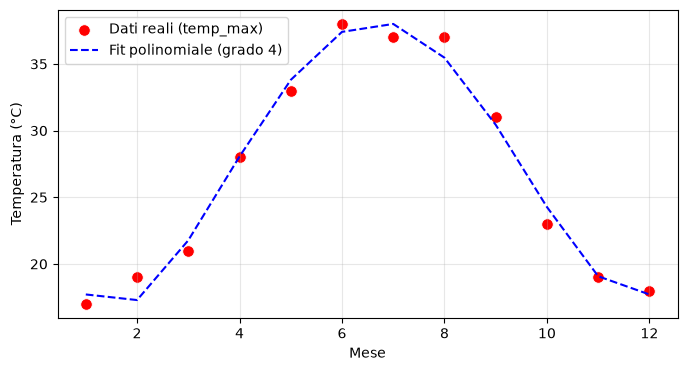

In [11]:
import seaborn as sns

x_mesi = np.arange(1, 13)
y_dati = temp_max 
grado = 4
coeff = np.polyfit(x_mesi, y_dati, grado)
y_pred = np.polyval(coeff, x_mesi)

# MAE e RMSE
mae = np.mean(np.abs(y_dati - y_pred))
rmse = np.sqrt(np.mean((y_dati - y_pred) ** 2))

print(f"MAE: {mae:.4f}")
print(f"RMSE: {rmse:.4f}")

plt.figure(figsize=(8, 4))
sns.scatterplot(x=x_mesi, y=y_dati, color='red', s=70, label='Dati reali (temp_max)')
plt.plot(x_mesi, y_pred, color='blue', label=f'Fit polinomiale (grado {grado})', linestyle='--')
plt.xlabel('Mese')
plt.ylabel('Temperatura (°C)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

### **3. Modello di regressione lineare dei seguenti dati**

 Calcola un modello di regressione lineare delle colonne mpg e disp del famoso dataset mtcars.

Dove: 

mpg = Miles Per Gallon → miglia per gallone, cioè una misura del consumo di carburante. Più alto è il valore, più efficiente è l’auto.

disp = Displacement → cilindrata del motore, in pollici cubici (cubic inches). Rappresenta il volume totale dei cilindri del motore. Più è alto, maggiore è la potenza potenziale del motore (ma anche il consumo).

In [10]:
import pandas as pd

# Load dataset from URL
df = pd.read_csv('https://gist.githubusercontent.com/seankross/a412dfbd88b3db70b74b/raw/5f23f993cd87c283ce766e7ac6b329ee7cc2e1d1/mtcars.csv')

# Display the dataframe
df


,model,mpg,cyl,disp,hp,drat,wt,qsec,vs,am,gear,carb
0,Mazda RX4,21.0,6,160.0,110,3.90,2.620,16.46,0,1,4,4
1,Mazda RX4 Wag,21.0,6,160.0,110,3.90,2.875,17.02,0,1,4,4
2,Datsun 710,22.8,4,108.0,93,3.85,2.320,18.61,1,1,4,1
3,Hornet 4 Drive,21.4,6,258.0,110,3.08,3.215,19.44,1,0,3,1
4,Hornet Sportabout,18.7,8,360.0,175,3.15,3.440,17.02,0,0,3,2
5,Valiant,18.1,6,225.0,105,2.76,3.460,20.22,1,0,3,1
6,Duster 360,14.3,8,360.0,245,3.21,3.570,15.84,0,0,3,4
7,Merc 240D,24.4,4,146.7,62,3.69,3.190,20.00,1,0,4,2
8,Merc 230,22.8,4,140.8,95,3.92,3.150,22.90,1,0,4,2
9,Merc 280,19.2,6,167.6,123,3.92,3.440,18.30,1,0,4,4


Coefficiente di determinazione (R²): 0.7183


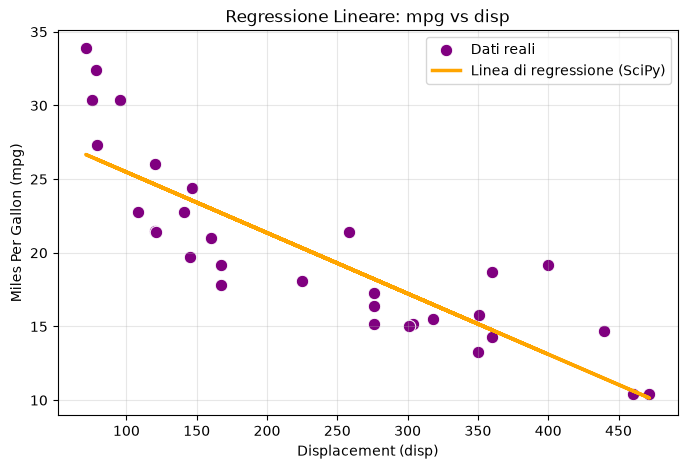

In [ ]:
import seaborn as sns
from scipy import stats
import matplotlib.pyplot as plt

x = df['disp']
y = df['mpg']

slope, intercept, r_value, p_value, std_err = stats.linregress(x, y)
print(f"Coefficiente di determinazione (R²): {r_value**2:.4f}")
plt.figure(figsize=(8, 5))
sns.scatterplot(data=df, x='disp', y='mpg', color='purple', s=80, label='Dati reali')
y_pred = slope * x + intercept
plt.plot(x, y_pred, color='orange', linewidth=2.5, label='Linea di regressione (SciPy)')
plt.xlabel('Displacement (disp)')
plt.ylabel('Miles Per Gallon (mpg)')
plt.title('Regressione Lineare: mpg vs disp')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()